# Cost Function and Gradient Descent

## Quick, easy revision notes
A Simple Linear Regression model needs to find the **best** line. The cost function tells us how bad a line is; Gradient Descent helps us improve the line.

## The goal
The model uses a line to predict values:

$$ŷ = θ_0 + θ_1x$$

- $θ_0$ moves the line up or down (intercept).
- $θ_1$ tilts the line (slope).

We keep changing these two values until the line's mistakes are as small as possible.

## Error and cost
For one data point:

$$error = ŷ - y$$

This is the gap between the model's answer and the real answer. We square every gap, add them, and average them.

$$J(θ_0, θ_1) = (1 / 2m) ∑_{i=1}^{m} (ŷ^{(i)} - y^{(i)})^2$$

This is called a cost function. Small $J$ means a better line. The squared part makes big mistakes count more and stops positive and negative errors from cancelling each other.


In simple words:

A **cost function** is a score that tells us how wrong a line’s predictions are.

- $J$ is the error score.
- **Small \(J\)** means the predictions are close to the actual values, so the line is better.
- We square each error before adding it:
  - This makes large errors much more noticeable.
  - It prevents positive and negative errors from cancelling out.

### Example

Suppose two prediction errors are:

$$
+3 \quad \text{and} \quad -3
$$

Without squaring:

$$
3 + (-3) = 0
$$

This incorrectly looks like there is no error.

After squaring:

$$
3^2 + (-3)^2 = 9 + 9 = 18
$$

Now both mistakes are counted properly. The cost function therefore gives a high score when the line makes large mistakes and a low score when it fits the data well.

## A tiny example
Use three real points: $(1, 1)$, $(2, 2)$, and $(3, 3)$. For an easy picture, pretend $θ_0 = 0$, so the line is:

$$ŷ = θ_1x$$

- If $θ_1 = 1$, the line goes through every point. Cost is 0.
- If $θ_1 = 0.5$, the line is too flat. It makes mistakes.
- If $θ_1 = 0$, the line is flat on the x-axis. It makes even bigger mistakes.

### Simple explanation
$θ_1$ controls how steep the line is. When $θ_1 = 1$, the model predicts $1, 2,$ and $3$, exactly matching the real values, so the cost is 0. When $θ_1 = 0.5$, the line is not steep enough and its predictions are too small. When $θ_1 = 0$, the model always predicts 0, so its mistakes are even larger.

Setting $θ_0 = 0$ is only for this simple drawing. In a real model, both $θ_0$ and $θ_1$ can change.

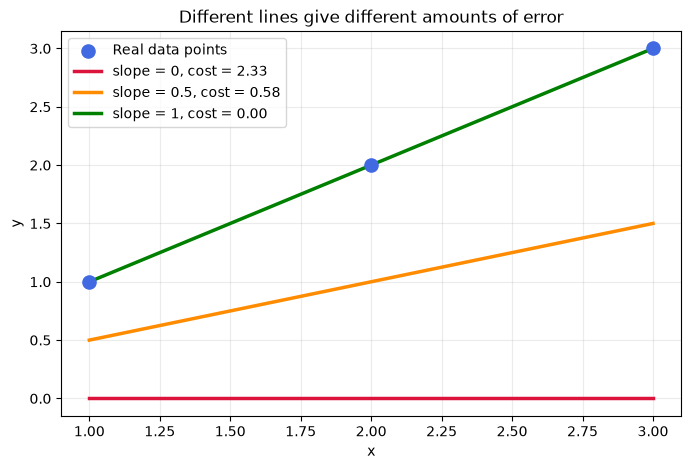

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1, 2, 3])
y = np.array([1, 2, 3])
candidate_slopes = [0, 0.5, 1]
colors = ['crimson', 'darkorange', 'green']

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, color='royalblue', s=90, zorder=4, label='Real data points')

for slope, color in zip(candidate_slopes, colors):
    predicted = slope * x
    cost = np.mean((predicted - y) ** 2) / 2
    ax.plot(x, predicted, color=color, linewidth=2.5, label=f'slope = {slope}, cost = {cost:.2f}')

# The green line touches every blue dot, so its errors disappear and its cost is zero.
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Different lines give different amounts of error')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

### What the first diagram means
- Blue dots are the real answers.
- Red and orange lines miss the dots, so their cost is bigger.
- Green line touches all dots, so its cost is 0.

The model wants the line that makes the smallest total squared mistake.

## The cost bowl and global minimum
If we try many slope values and calculate their costs, we get a bowl-shaped **cost curve**.

- A high place on the bowl means a bad line.
- The bottom of the bowl is the **global minimum**.
- At the bottom, the model has the smallest cost and the best line.

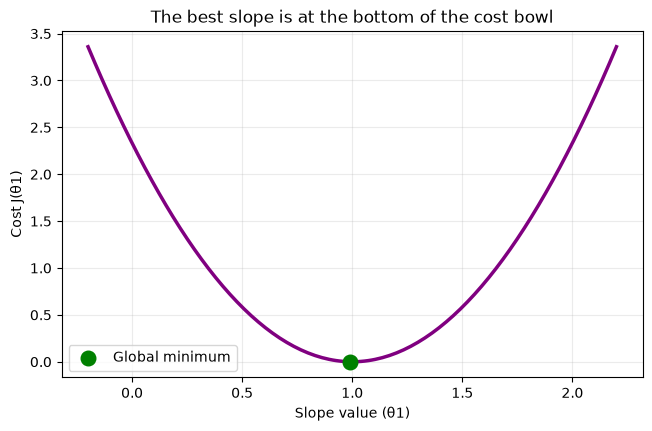

Best slope: 0.99
Smallest cost: 0.0002


In [2]:
possible_slopes = np.linspace(-0.2, 2.2, 150)
costs = []

for slope in possible_slopes:
    predicted = slope * x
    costs.append(np.mean((predicted - y) ** 2) / 2)

best_index = int(np.argmin(costs))
best_slope = possible_slopes[best_index]

plt.figure(figsize=(7.5, 4.5))
plt.plot(possible_slopes, costs, color='purple', linewidth=2.5)
plt.scatter(best_slope, costs[best_index], color='green', s=110, zorder=3, label='Global minimum')
plt.xlabel('Slope value (θ1)')
plt.ylabel('Cost J(θ1)')
plt.title('The best slope is at the bottom of the cost bowl')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

print(f'Best slope: {best_slope:.2f}')
print(f'Smallest cost: {costs[best_index]:.4f}')

### What the second diagram means
The purple curve is the cost curve, not the data line. It answers this question: “If I choose this slope, how much total error will I get?”

The green point is the lowest place. That slope makes the best line for this tiny dataset.

## Gradient Descent: how the model knows which way to walk
Trying every possible slope is slow for big data. **Gradient Descent** is a method that walks downhill on the cost bowl.

1. Start with any values for $θ_0$ and $θ_1$.
2. Check the slope of the cost bowl at the current place.
3. Take a small step in the downhill direction.
4. Repeat until the cost hardly changes.

The update rule is:

$$θ_j := θ_j - α\frac{∂J(θ)}{∂θ_j}$$

Do not let the symbols scare you. $\frac{∂J}{∂θ_j}$ simply means **the slope of the cost bowl** for the parameter we are changing. We subtract it because subtracting points us downhill.

- **Negative slope:** we are on the left side of the bowl. `old − α × negative` becomes bigger, so $θ$ increases and moves right.
- **Positive slope:** we are on the right side of the bowl. `old − α × positive` becomes smaller, so $θ$ decreases and moves left.
- **Slope near zero:** we are near the bottom, so the updates become tiny.

For the simple linear-regression cost bowl, the bottom is the **global minimum**: the smallest possible cost. Reaching it (or getting very close) gives the best-fit line.

### Learning rate ($α$) = step size
- Too small: the model takes baby steps and learns very slowly.
- A useful size: the model walks smoothly toward the bottom.
- Too large: the model may jump over the bottom again and again and never settle.

Values such as $0.001$ or $0.01$ are common starting points, but the best choice depends on the data.

## One-minute revision
- Error = predicted value minus real value.
- Cost function = one number that tells how bad the whole line is.
- MSE squares errors, so big mistakes matter more.
- Global minimum = smallest cost = best line.
- Gradient Descent uses `new θ = old θ − learning rate × cost slope` to walk down the cost bowl.

**Memory trick:** `bad line → big cost; best line → bottom of bowl.`